In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
# np.random.seed(42) - ensures same randomness every run - reproducibility and consistency

# PART 1 - Understanding Returns and Covariance Structure

In [2]:
n_stocks = 10
n_days = 500
initial_price = 100
# same start because we want to emerge differences due to drift, beta and volatility.

In [3]:
mu = np.random.uniform(0.0001, 0.0005, n_stocks)
beta = np.random.uniform(0.5, 1.5, n_stocks)
sigma = np.random.uniform(0.005, 0.02, n_stocks)

In [4]:
market_factor = np.random.normal(0, 0.01, n_days)
# ft - represents the overall market movement, this is used by all stocks in their price eqn.

# (a)
Generate 500 days of prices for 10 stocks using the process above. Choose reasonable
parameters: Pi,0 = 100, μi ~ U(0.0001, 0.0005), βi ~ U(0.5, 1.5), σi ~ U(0.005, 0.02). Plot all 10
price series on a single chart.

In [5]:
prices = np.zeros((n_days, n_stocks))
prices[0] = initial_price
# 500 days x 10 stocks matrix

In [6]:
# stock price generation code
for t in range(1, n_days):
    epsilon = np.random.normal(0, sigma)
    # individual random shock for each stock
    prices[t] = ( prices[t-1] * np.exp(mu + beta * market_factor[t] + epsilon))

In [7]:
# creating dataframe - for easier plotting and heatmaps further
stock_names = [f"Stock_{i+1}" for i in range(n_stocks)]
prices_df = pd.DataFrame(prices, columns=stock_names)
prices_df.head()
# shows first 5 rows here, for more rows can change to prices_df.head(x) where x is number of rows visbile. 


,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5,Stock_6,Stock_7,Stock_8,Stock_9,Stock_10
0,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
1,97.934694,100.636391,100.786630,99.354544,101.033869,97.516709,100.261987,98.896156,99.480375,100.363246
2,96.469326,99.527894,100.971323,98.366555,101.638091,95.309313,100.214723,100.152013,95.619944,99.473089
3,97.138520,99.006996,100.970142,97.575202,101.556699,94.886798,100.930177,100.221333,95.841086,99.049136
4,96.191620,97.881580,100.574733,96.762377,101.505026,97.861696,101.157403,99.237563,96.941204,98.387493


In [8]:
prices_df.to_csv("../data/synthetic_prices.csv", index=False)

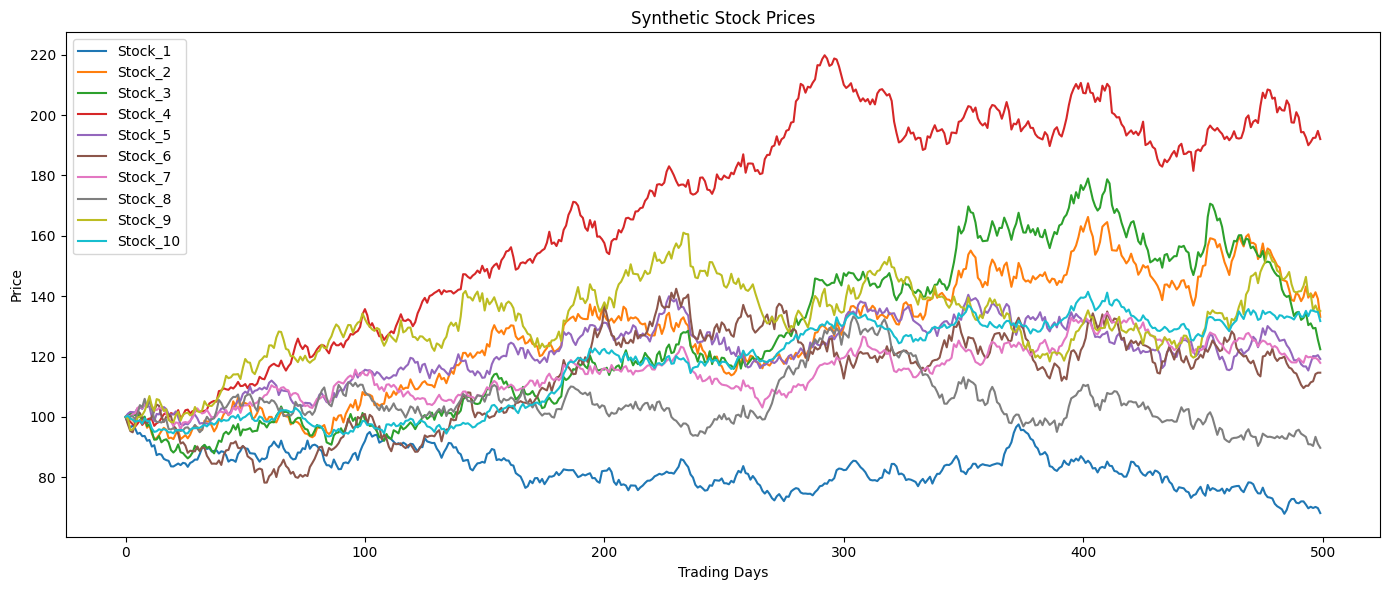

In [9]:
#plots 
plt.figure(figsize=(14,6))
for col in prices_df.columns:
    plt.plot(prices_df[col], label=col)
plt.title("Synthetic Stock Prices")
plt.xlabel("Trading Days")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.savefig("../plots/price_series.png")
plt.show()

# (b)
Compute daily log returns: ri,t = ln(Pi,t / Pi,t−1). Explain in a markdown cell why PCA must be
performed on returns (or a stationary transformation) rather than on prices directly.

In [10]:
# log returns
log_returns = np.log(prices_df / prices_df.shift(1))
log_returns = log_returns.dropna()
# dropna so that first row becomes NaN as day0 has no previous day.
display(log_returns.head())
# gives 499x10 matrix

,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5,Stock_6,Stock_7,Stock_8,Stock_9,Stock_10
1,-0.020869,0.006344,0.007836,-0.006475,0.010286,-0.025146,0.002616,-0.011100,-0.005210,0.003626
2,-0.015076,-0.011076,0.001831,-0.009994,0.005963,-0.022896,-0.000472,0.012619,-0.039579,-0.008909
3,0.006913,-0.005247,-0.000012,-0.008077,-0.000801,-0.004443,0.007114,0.000692,0.002310,-0.004271
4,-0.009796,-0.011432,-0.003924,-0.008365,-0.000509,0.030871,0.002249,-0.009864,0.011413,-0.006702
5,-0.019004,0.020557,0.007521,0.009845,0.013010,0.040948,0.017634,0.016642,0.029120,0.002443


In [11]:

log_returns.to_csv("../data/log_returns.csv", index=False)

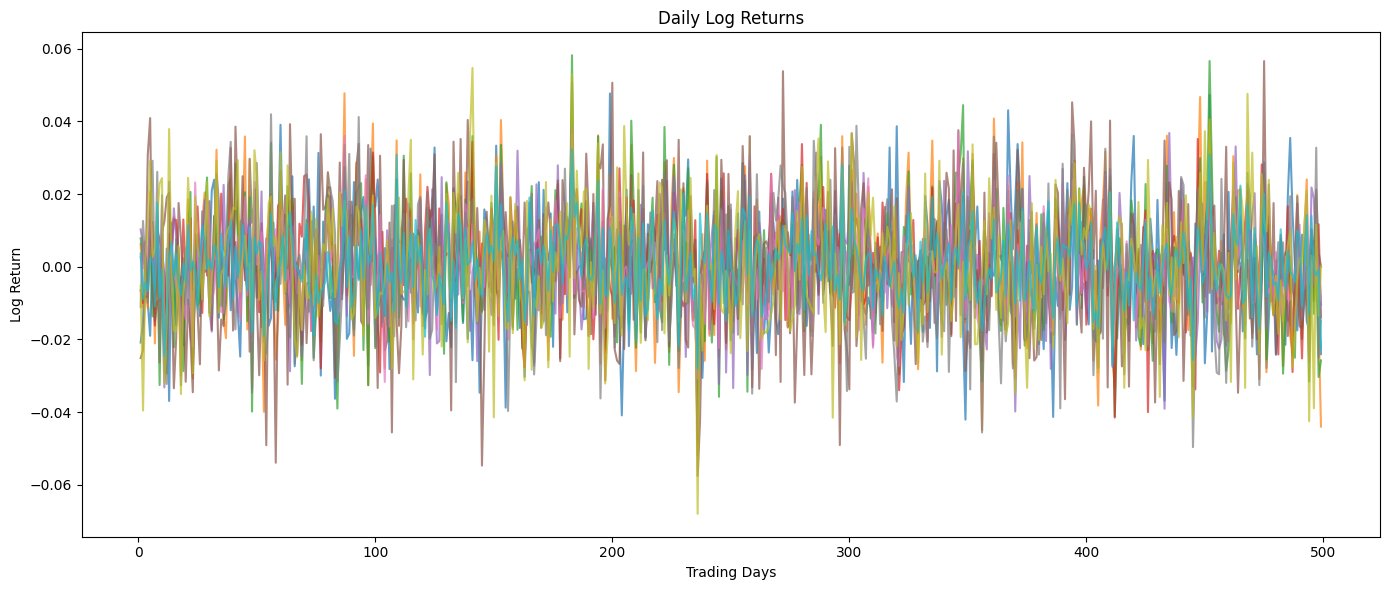

In [12]:
# log returns plot - to support reasoning to part (b)
plt.figure(figsize=(14,6))
for col in log_returns.columns:
    plt.plot(log_returns[col], alpha=0.7)
plt.title("Daily Log Returns")
plt.xlabel("Trading Days")
plt.ylabel("Log Return")
plt.tight_layout()
plt.savefig("../plots/log_returns.png")
plt.show()

# Explain in a markdown cell why PCA must be performed on returns (or a stationary transformation) rather than on prices directly

# Solution -

PCA should be applied to returns rather than stock prices because stock prices are generally
- non-stationary
- consist long term trends
- they evolve over time and are heavily influenced by scale, which makes direct comparision between the assets unreliable.
For example,
- A stock priced around 500 may contribute much larger numerical variations than a stock priced around 50, even if both move similarly in percentage terms.

Daily log returns remove much of this trend and scale dependence by measuring relative percentage movement between consecutive trading days. Using returns provide several advantages such as -
- returns are more stationary than prices.
- It is easier to analyze volatility in case of returns.
- Assets become comparable irrespective of price scale.
- Covariance and correlation structures become more meaningful.
- PCA is able to identify latent common market factors instead of simple price-level differences.

The visualization of log returns plotted above further confirms this behavior. Unlike prices, which exhibit long-term trending patterns, returns fluctuate around zero and display relatively stable variance over time. This makes returns statistically more suitable for covariance analysis and dimensionality reduction using PCA.

Therefore, returns provide a cleaner representation of the true dependency structure between assets and form the appropriate input for PCA.

# (c)

Compute the 10×10 correlation matrix and the 10×10
covariance matrix of the returns. Visualize
both as heatmaps. Identify which pair of stocks has the highest and lowest correlation

In [13]:
#correlation and covariance matrices
correlation_matrix = log_returns.corr()
covariance_matrix = log_returns.cov()
display(correlation_matrix)
display(covariance_matrix)

,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5,Stock_6,Stock_7,Stock_8,Stock_9,Stock_10
Stock_1,1.000000,0.320880,0.304488,0.148427,0.193885,0.155942,0.274627,0.180794,0.199914,0.313248
Stock_2,0.320880,1.000000,0.758583,0.513821,0.498209,0.275130,0.650398,0.548901,0.501024,0.704862
Stock_3,0.304488,0.758583,1.000000,0.510424,0.395707,0.268143,0.604958,0.516400,0.437364,0.637563
Stock_4,0.148427,0.513821,0.510424,1.000000,0.288422,0.197022,0.422605,0.407971,0.338690,0.450649
Stock_5,0.193885,0.498209,0.395707,0.288422,1.000000,0.214227,0.422022,0.318336,0.298716,0.404811
Stock_6,0.155942,0.275130,0.268143,0.197022,0.214227,1.000000,0.222752,0.170375,0.237671,0.250297
Stock_7,0.274627,0.650398,0.604958,0.422605,0.422022,0.222752,1.000000,0.442211,0.405379,0.543591
Stock_8,0.180794,0.548901,0.516400,0.407971,0.318336,0.170375,0.442211,1.000000,0.288745,0.506067
Stock_9,0.199914,0.501024,0.437364,0.338690,0.298716,0.237671,0.405379,0.288745,1.000000,0.424168
Stock_10,0.313248,0.704862,0.637563,0.450649,0.404811,0.250297,0.543591,0.506067,0.424168,1.000000


,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5,Stock_6,Stock_7,Stock_8,Stock_9,Stock_10
Stock_1,0.000233,0.000081,0.000075,0.000028,0.000040,0.000045,0.000047,0.000044,0.000052,0.000046
Stock_2,0.000081,0.000272,0.000202,0.000104,0.000110,0.000086,0.000120,0.000143,0.000140,0.000112
Stock_3,0.000075,0.000202,0.000261,0.000101,0.000086,0.000082,0.000109,0.000132,0.000119,0.000099
Stock_4,0.000028,0.000104,0.000101,0.000150,0.000047,0.000045,0.000058,0.000079,0.000070,0.000053
Stock_5,0.000040,0.000110,0.000086,0.000047,0.000180,0.000054,0.000063,0.000067,0.000068,0.000052
Stock_6,0.000045,0.000086,0.000082,0.000045,0.000054,0.000355,0.000047,0.000051,0.000076,0.000045
Stock_7,0.000047,0.000120,0.000109,0.000058,0.000063,0.000047,0.000125,0.000078,0.000077,0.000058
Stock_8,0.000044,0.000143,0.000132,0.000079,0.000067,0.000051,0.000078,0.000249,0.000077,0.000077
Stock_9,0.000052,0.000140,0.000119,0.000070,0.000068,0.000076,0.000077,0.000077,0.000286,0.000069
Stock_10,0.000046,0.000112,0.000099,0.000053,0.000052,0.000045,0.000058,0.000077,0.000069,0.000093


In [14]:

correlation_matrix.to_csv("../data/correlation_matrix.csv")
covariance_matrix.to_csv("../data/covariance_matrix.csv")

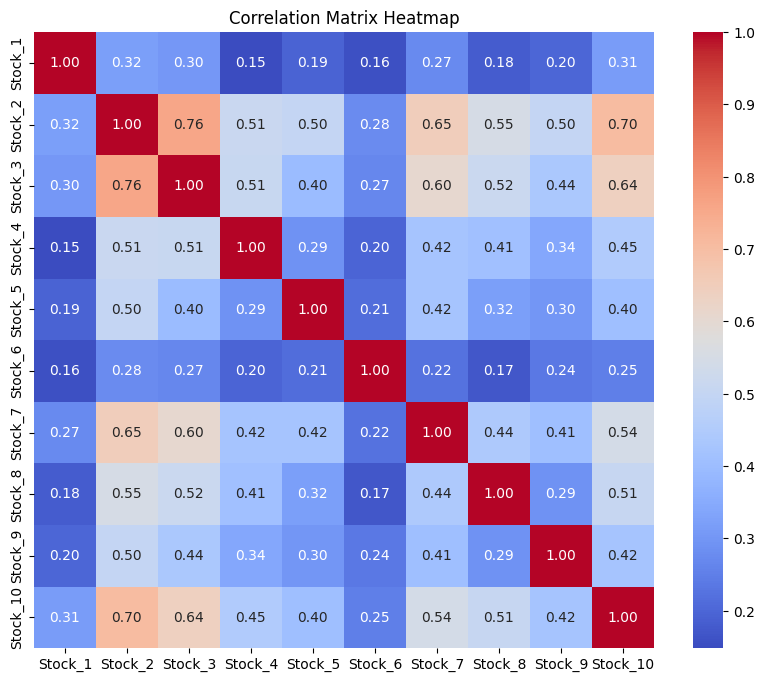

In [15]:
#correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix Heatmap")
plt.savefig("../plots/correlation_heatmap.png")
plt.show()

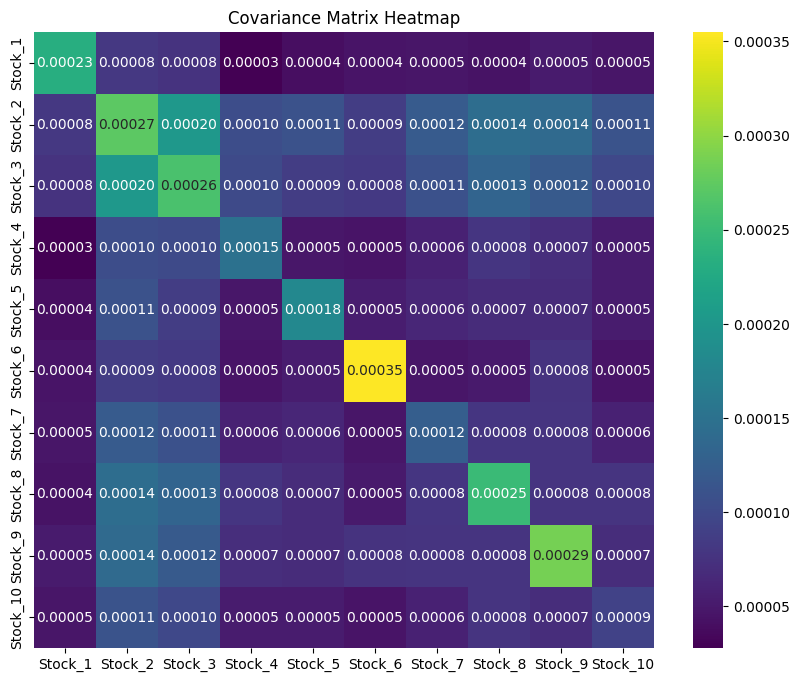

In [16]:
#covariance heatmap
plt.figure(figsize=(10,8))
sns.heatmap(
    covariance_matrix,
    annot=True,
    cmap="viridis",
    fmt=".5f"
)
plt.title("Covariance Matrix Heatmap")
plt.savefig("../plots/covariance_heatmap.png")
plt.show()

In [17]:
# highest and lowest correlation pairs

corr_pairs = correlation_matrix.unstack()
# remove self correlation as we do not want stock's correlation with itself, that will give 1.0
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]
# Remove duplicate pairs - as correlation matrix is symmetric - duplicate pairs may occur
corr_pairs = corr_pairs.drop_duplicates()
highest_corr = corr_pairs.idxmax()
lowest_corr = corr_pairs.idxmin()
print("Highest Correlation Pair:", highest_corr)
print("Correlation Value:", corr_pairs.max())
print()
print("Lowest Correlation Pair:", lowest_corr)
print("Correlation Value:", corr_pairs.min())

Highest Correlation Pair: ('Stock_2', 'Stock_3')
Correlation Value: 0.7585826477430198

Lowest Correlation Pair: ('Stock_1', 'Stock_4')
Correlation Value: 0.14842696873250696


# Observation from Correlation and Covariance Analysis 

- The correlation heatmap shows that many stocks move together because all of them are influenced by the same common market factor used in the data generation process.
- Some stock pairs show stronger correlation than others because certain stocks react more strongly to market movements due to higher beta values.
- The covariance matrix shows how the returns of different stocks vary together. Stocks with larger fluctuations generally produce larger covariance values.
- Overall, the heatmaps indicate that the stocks are not independent and share an underlying relationship structure. This hidden structure is what PCA later tries to identify and summarize using a smaller number of principal components.
- The highest correlation pair corresponds to the two stocks that move most similarly, while the lowest correlation pair corresponds to stocks with relatively weak or less similar movements.

# (d)

Standardize the returns to zero mean and unit variance. Explain why standardization matters when stocks have different volatilities. What happens to PCA results if you skip this step?


In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
# Standardize returns

scaler = StandardScaler()
# creates scaling object
standardized_returns = scaler.fit_transform(log_returns)
# standardize to make each stock's mean =0 and standard deviation = 1.
standardized_returns = pd.DataFrame(
    standardized_returns,
    columns=log_returns.columns
)
display(standardized_returns.head())

,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5,Stock_6,Stock_7,Stock_8,Stock_9,Stock_10
0,-1.317191,0.349922,0.460416,-0.635845,0.740845,-1.350615,0.204899,-0.690553,-0.344059,0.319819
1,-0.937532,-0.706486,0.088337,-0.923275,0.418441,-1.231057,-0.071812,0.814423,-2.378358,-0.984583
2,0.503418,-0.353017,-0.025836,-0.766717,-0.085982,-0.250610,0.607911,0.057647,0.101038,-0.501960
3,-0.591525,-0.728084,-0.268248,-0.790219,-0.064192,1.625648,0.171954,-0.612168,0.639850,-0.754962
4,-1.194929,1.211895,0.440942,0.697418,0.944010,2.161051,1.550606,1.069718,1.687908,0.196694


In [ ]:

standardized_returns.to_csv(
    "../data/standardized_returns.csv",
    index=False
)

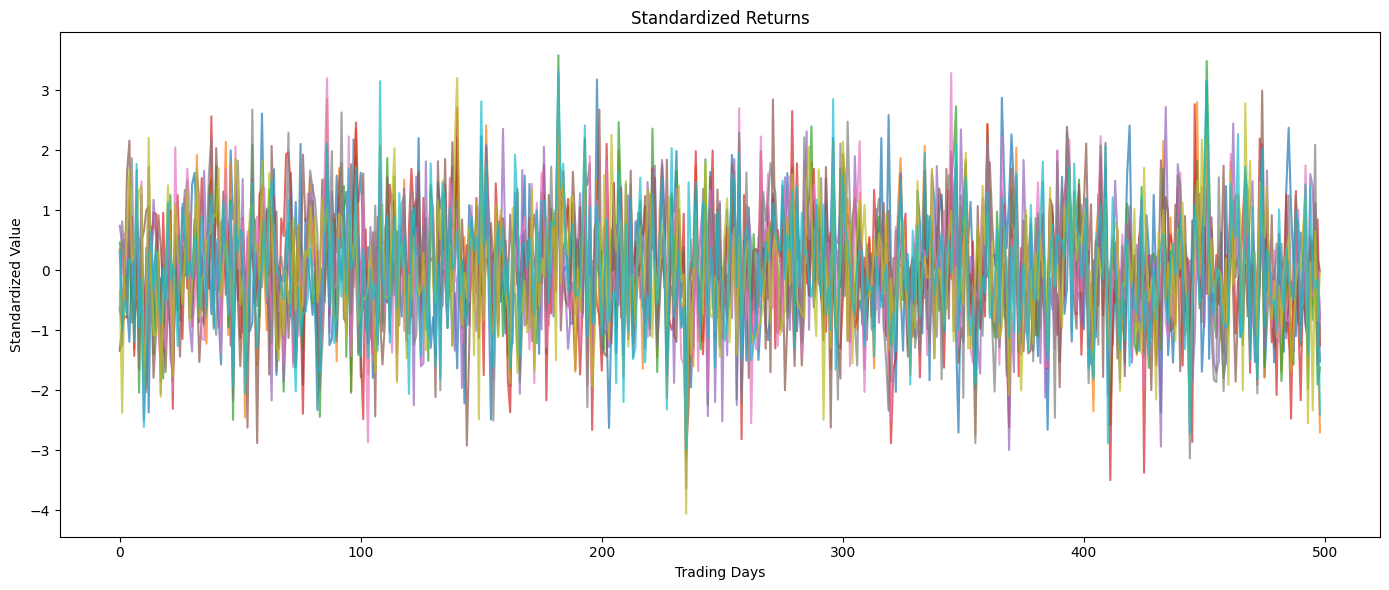

In [20]:
# Plot standardized returns - visual proof of standardization worked.

plt.figure(figsize=(14,6))
for col in standardized_returns.columns:
    plt.plot(standardized_returns[col], alpha=0.7)
plt.title("Standardized Returns")
plt.xlabel("Trading Days")
plt.ylabel("Standardized Value")
plt.tight_layout()
plt.savefig("../plots/standardized_returns.png")
plt.show()

# Explain why standardization matters when stocks have different volatilities. What happens to PCA results if you skip this step?

# Solution -

Currently our stocks have different volatilities, some stocks fluctuate alot, some very little. Now beacuse PCA works by finding directions with maximum variance, so naturally, high volatlity stocks produce larger variance and PCA will start focusing on them mostly even if othr stocks contain important structures. So to avoid PCA becoming biased towards magnitude of movement instead of focusing on actual relationship structure, standardization is important.

Standardization transform each stock's returns so that
- mean becomes 0
- variance becomes 1
So all stocks now contribute equally to PCA regardless of their original volatility levels.

The standardized return visualization further confirms this effect. Before standardization, some stocks fluctuate much more strongly than others. After scaling, the return series appear on a comparable scale, preventing any single stock from dominating the analysis purely because of higher volatility.

As a result, PCA is able to focus on the true correlation structure and common market behavior rather than differences in variance magnitude.

If standardization is skipped, the first few principal components may become biased toward only the most volatile stocks, leading to less meaningful factor interpretation.


# (e)

 Write down all your observations.

# Observations from PART 1

- The generated stock prices showed realistic market-like movement over time.

- Since all stocks were affected by the same common market factor, many of them moved together, creating correlation between assets.

- Stocks with higher beta values reacted more strongly to market changes and therefore showed larger upward or downward movements.

- Converting prices into log returns removed most of the long-term trend and made the data more stable for analysis.

- The correlation and covariance heatmaps showed that the stocks were not independent and shared common movement patterns.

- Some stock pairs had strong correlation because they reacted similarly to the market factor, while others showed weaker relationships due to random stock-specific noise.

- Standardization placed all return series on a similar scale by making their mean close to 0 and variance close to 1.

- After standardization, no single stock dominated the analysis simply because of higher volatility.

- Overall, the dataset showed a clear hidden market structure, making it suitable for applying PCA in the next part of the project.